# Setup / Utils

In [23]:
import torch
from torch.utils.data import random_split
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash
from collections import defaultdict


In [24]:
N_SAMPLES = 1000

In [25]:
def construct_adj_matrix(edge_index, batch): 
    graphs, g_sizes = torch.unique(batch, return_counts=True)
    max_size = torch.max(g_sizes)
    A = torch.zeros((len(graphs), max_size, max_size))
    gs = torch.tensor([graphs[batch[e]] for e in edge_index[0]])
    
    global_to_local_idx = torch.hstack([torch.arange(g_size) for g_size in g_sizes])
    A[gs, global_to_local_idx[edge_index[0]], global_to_local_idx[edge_index[1]]] = 1
    # A = A + A.permute(0, 2, 1) # Edges both ways - Already is 
    return A 

## Dataset 

In [26]:
# %% Device
device = 'cpu'

# %% Load the MUTAG dataset
# Load data
dataset = TUDataset(root='./data/', name='MUTAG').to(device)
node_feature_dim = 7

# Split into training and validation
rng = torch.Generator().manual_seed(0)
train_dataset, validation_dataset, test_dataset = random_split(dataset, (100, 44, 44), generator=rng)

# Create dataloader for training and validation
train_loader = DataLoader(train_dataset, batch_size=100)
validation_loader = DataLoader(validation_dataset, batch_size=44)
test_loader = DataLoader(test_dataset, batch_size=44)

## Plotting 

In [27]:
def draw_graphs(As_ordered : np.ndarray, node_counts : np.ndarray) -> None:
    """
    Draw a graph using NetworkX and Matplotlib
    
    Args:
        As_ordered (np.ndarray): Adjacency matricies of graphs. Each adjacency matrix is assumed to be
        ordered by the node degree.
        node_counts (np.ndarray): Number of nodes in each graph
    """
    
    
    w = np.ceil(np.sqrt(len(As_ordered))).astype(int)  # Number of rows
    h = np.ceil(len(As_ordered) / w).astype(int)  # Number of columns
    plt.figure(figsize=(w * 5, h * 5))  # Set the figure size
    for i, A in enumerate(As_ordered):
        
        num_nodes = node_counts[i]
        ax = plt.subplot(h, w, i + 1)
        
        A = A[:num_nodes,:num_nodes].astype(int)  # Ensure the adjacency matrix is binary
        G = nx.from_numpy_array(A)  # Create a graph from the adjacency matrix
    
        nx.draw(G, ax=ax, node_size=int(200/w))
        
        rect = patches.Rectangle((0, 0), 1, 1,             # Coordinates and size
                                 transform=ax.transAxes,   # Use Axes coordinates
                                 linewidth=1,
                                 edgecolor='black',
                                 facecolor='none',         # No fill
                                 clip_on=False,            # Draw lines even if slightly outside bounds
                                 zorder=10)                # Draw on top

        # Add the rectangle to the Axes
        ax.add_patch(rect)

# Baseline 

In [28]:
def generate_Erdos_Renyi(dataset, n_samples = 1000):
    
    def generate_graph_Erdos_Renyi(num_nodes, p):
        """Generate a random graph with the given number of nodes and edge density"""
        # For each node pair make an edge there with propability p 
        # NOTE : we do it for a complete square matrix but only use the upper triangle
        A = np.random.rand(num_nodes, num_nodes) < p
        A = np.triu(A, 1) + np.triu(A, 1).T
        
        # TODO : why do we reorder? 
        # A = reorder_adj_matrix_by_degree(A)
        
        return A
    
    # Compute the link propability for each size graph 
    n_links_size_graph = defaultdict(list)
    n_nodes = defaultdict(lambda: 0)
    dl = DataLoader(dataset=dataset, batch_size=1)
    for batch in dl: 
        n_edges = batch['edge_index'].shape[1]
        n_vertices = len(batch['batch'])
        n_links_size_graph[n_vertices].append(n_edges)
        n_nodes[n_vertices] += 1 
    
    link_prob = {n_nodes: 2*np.mean(n_links) / (n_nodes**2 - n_nodes) for n_nodes, n_links in n_links_size_graph.items()}
    
    # Sample new graphs with num_nodes drawn from the distribution of number of nodes
    all_num_nodes = np.random.choice(np.array(list(n_nodes.keys())), n_samples, replace = True, p=np.array(list(n_nodes.values()))/sum(n_nodes.values()))
    max_num_nodes = np.max(all_num_nodes)
    As = np.zeros((n_samples, max_num_nodes, max_num_nodes), dtype=int)
    for i, num_nodes in tqdm(enumerate(all_num_nodes)):
        # Get the edge density for the current node count
        p = link_prob[num_nodes]
        
        # Generate a random graph with the given number of nodes and edge density
        As[i, :num_nodes, :num_nodes] = generate_graph_Erdos_Renyi(num_nodes, p)

    return As, all_num_nodes


In [29]:
baseline_As, baseline_node_counts = generate_Erdos_Renyi(train_dataset, N_SAMPLES)

1000it [00:00, 34296.89it/s]


# VAE 

In [30]:
class GEncoder(torch.nn.Module): 
    def __init__(self, node_feature_dim, out_feature_dim, state_dim, num_message_passing_rounds):
        super().__init__()
        self.node_feature_dim = node_feature_dim
        self.out_feature_dim = out_feature_dim
        self.state_dim = state_dim
        self.num_message_passing_rounds = num_message_passing_rounds 
        
        # Encoder for nodes net 
        self.node_encoder = torch.nn.Sequential(
            torch.nn.Linear(self.node_feature_dim, self.state_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(self.state_dim, self.state_dim),
            torch.nn.ReLU()
            )

        # Message networks
        self.message_net = torch.nn.ModuleList([
            torch.nn.Sequential(
                torch.nn.Linear(self.state_dim, self.state_dim),
                torch.nn.ReLU(),
                torch.nn.Linear(self.state_dim, self.state_dim),
                torch.nn.ReLU()
            ) for _ in range(num_message_passing_rounds)])
        
        self.dropout = torch.nn.Dropout(0.0)

        # Update network
        # self.update_net = torch.nn.ModuleList([
        #     torch.nn.Sequential(
        #         torch.nn.Linear(self.state_dim, self.state_dim),
        #         torch.nn.ReLU(),
        #         torch.nn.Linear(self.state_dim, self.state_dim),
        #         torch.nn.ReLU()
        #     ) for _ in range(num_message_passing_rounds)])
        self.grus = torch.nn.ModuleList([
            torch.nn.GRU(self.state_dim, hidden_size=self.state_dim, dropout=0.0, num_layers=1) for _ in range(num_message_passing_rounds)
        ])
    
        # Output encoder net 
        self.output_net = torch.nn.Linear(self.state_dim, self.out_feature_dim*2)
    
    def forward(self, x, edge_index, batch):
        # Extract number of nodes and graphs
        num_graphs = batch.max()+1
        num_nodes = batch.shape[0]

        # Initialize node state from node features
        state = self.node_encoder(x)
    
        # Loop over message passing rounds
        for r in range(self.num_message_passing_rounds):
            # Compute outgoing messages
            message = self.dropout(self.message_net[r](state))

            # Aggregate: Sum messages
            aggregated = x.new_zeros((num_nodes, self.state_dim))
            aggregated = aggregated.index_add(0, edge_index[1], message[edge_index[0]])

            # Update states
            # state = state + self.update_net[r](aggregated)
            state = self.grus[r](aggregated.unsqueeze(0), state.repeat(1, 1, 1))[0].squeeze()

        # Aggretate: Sum node features
        # graph_state = x.new_zeros((num_graphs, self.state_dim))
        # graph_state = torch.index_add(graph_state, 0, batch, state)

        # Output
        out = self.output_net(state)
        return out

class GDecoder(torch.nn.Module): 
    def __init__(self, in_dim): 
        super().__init__()
        self.in_dim = in_dim 
        
        self.bilinear_layer = torch.nn.Bilinear(in_dim, in_dim, 1, bias=False)
        self.mlp = torch.nn.Sigmoid()
        # self.mlp = torch.nn.Sequential(
        #     torch.nn.Linear(self.in_dim, self.in_dim), 
        #     torch.nn.ReLU(),
        #     torch.nn.Linear(self.in_dim, 1),
        #     torch.nn.Sigmoid()
        # )
        
    def forward(self, x, batch): 
        # Go through all pairs in each graph
        graphs, g_sizes = torch.unique(batch, return_counts=True)
        max_size = torch.max(g_sizes) 
        # As = torch.full((len(graphs), max_size, max_size), -torch.inf)
        As = torch.zeros((len(graphs), max_size, max_size)) 
        idxs = torch.empty((3,0), dtype=int)
        for i, g in enumerate(graphs):
            indices = torch.where(batch == g)[0]
            v = x[indices]
            idx_i, idx_j = torch.triu_indices(len(v), len(v), offset=1)
            
            feat = self.bilinear_layer(v[idx_i], v[idx_j]).squeeze()
            pred = self.mlp(feat)
            
            # Reorder back to the square matrix used for elbo
            idx_k = i*torch.ones_like(idx_i)
            As[idx_k, idx_i, idx_j] = pred.squeeze()
            As[idx_k, idx_j, idx_i] += pred.squeeze()
            
            idxs = torch.cat([idxs, torch.vstack([idx_k, idx_i, idx_j])], dim=1)
            
            # norms = torch.norm(v, dim=0)
            # CosSim = v @ v.T / torch.outer(norms, norms) 
        return As, idxs
            

class GVAE(torch.nn.Module): 
    def __init__(self, encoder, decoder, prior_mean=0, prior_std=1):
        super().__init__()
        # Encoder 
        self.encoder = encoder 
        # Decoder 
        self.decoder = decoder
        # Prior -> This is not used as I just assume they are 0 and 1 respectively
        self.prior_mean = prior_mean
        self.prior_std = prior_std 
        self.binary_cross_entropy = torch.nn.BCELoss() # torch.nn.BCEWithLogitsLoss()
        
    def negative_ELBO(self, As, At, mu, std, schedule): 
        # return self.binary_cross_entropy(As*0.9 + 1e-12, At)
        n_dim = std.shape[0]*std.shape[1]
        KL_term = 1/(n_dim)* 1/2 * (-torch.sum(torch.log(std)) - std.shape[0]*std.shape[1] + torch.sum(std) + torch.inner(torch.flatten(mu), torch.flatten(mu)))
        loglikelihood_term = self.binary_cross_entropy(As, At) #torch.sum(At * torch.log(As) + (1-At) * torch.log(1-As)) 
        
        return KL_term + loglikelihood_term
    
    def forward(self, x, edge_index, batch, schedule): 
        # Get node encoding distribution and sample from it 
        encodings = self.encoder(x, edge_index, batch)
        mu = encodings[:, :self.encoder.out_feature_dim]
        std = torch.exp(encodings[:, self.encoder.out_feature_dim:])
        
        # Reparameterization trick 
        e = torch.randn_like(std)
        samples = mu + e*std 
        
        # Predict with decoder 
        As, idxs = self.decoder(samples, batch)
        # As, idxs = self.decoder(x, batch)
        
        # Calculate the elbo
        At = construct_adj_matrix(edge_index=edge_index, batch=batch)
        loss = self.negative_ELBO(As[idxs[0], idxs[1], idxs[2]], At[idxs[0], idxs[1], idxs[2]], mu, std, schedule)
        
        return loss 
        


## Training

In [31]:
# Definitions 
# Model paramters 
node_feature_dim = 7
out_feature_dim = 40
state_dim = 20
num_message_passing_rounds = 10

# Model definition 
encoder = GEncoder(
            node_feature_dim=node_feature_dim, 
            out_feature_dim=out_feature_dim, 
            state_dim=state_dim, 
            num_message_passing_rounds=num_message_passing_rounds
        )

decoder = GDecoder(in_dim=out_feature_dim) 

vae = GVAE(encoder=encoder, decoder=decoder)

# Optimizer 
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.995)


In [32]:
epochs = 150
KL_annealing = 100
KL_annealing_schedule = torch.ones((epochs))
KL_annealing_schedule[:KL_annealing] = (KL_annealing - torch.arange(KL_annealing, 0, -1))/KL_annealing
with tqdm(range(epochs)) as pbar: 
    for epoch in pbar:
        # Loop over training batches
        vae.train()
        train_loss = 0.
        for data in train_loader:
            loss = vae(data.x, data.edge_index, batch=data.batch, schedule=KL_annealing_schedule[epoch])

            # Gradient step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute training loss and accuracy
            train_loss += loss.detach().cpu().item() * data.batch_size / len(train_loader.dataset)
        
        val_loss = 0
        vae.eval()
        for data in validation_loader:
            loss = vae(data.x, data.edge_index, batch=data.batch, schedule=KL_annealing_schedule[epoch])

            # Compute training loss and accuracy
            val_loss += loss.detach().cpu().item() * data.batch_size / len(validation_loader.dataset)
        
        
        pbar.set_description(f"Train ELBO {train_loss:.2f}, Val ELBO {train_loss:.2f}")
        # Learning rate scheduler step
        # scheduler.step()

Train ELBO 0.52, Val ELBO 0.52: 100%|██████████| 150/150 [00:39<00:00,  3.75it/s]


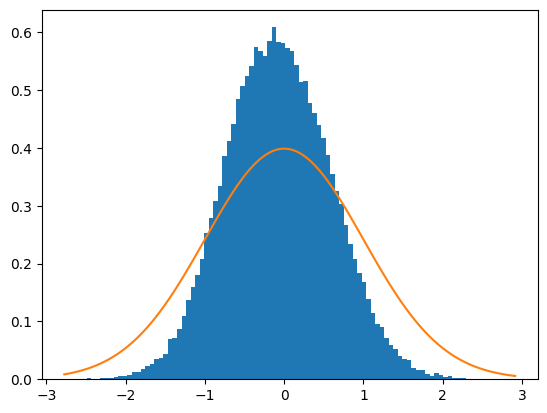

tensor([[0.0000, 0.1720, 0.0708, 0.0159, 0.1832, 0.1043, 0.0659, 0.0806, 0.0838,
         0.0128, 0.0193, 0.0264, 0.1599, 0.0068],
        [0.1720, 0.0000, 0.1928, 0.0616, 0.0840, 0.2793, 0.0212, 0.2817, 0.1826,
         0.0507, 0.0171, 0.0635, 0.2321, 0.0318],
        [0.0708, 0.1928, 0.0000, 0.1028, 0.5764, 0.3496, 0.1647, 0.0859, 0.0388,
         0.0684, 0.0950, 0.0655, 0.1263, 0.0453],
        [0.0159, 0.0616, 0.1028, 0.0000, 0.3255, 0.1016, 0.1954, 0.0443, 0.0240,
         0.0658, 0.0390, 0.0873, 0.1946, 0.0051],
        [0.1832, 0.0840, 0.5764, 0.3255, 0.0000, 0.2378, 0.2742, 0.4099, 0.0708,
         0.1872, 0.1227, 0.3708, 0.2507, 0.1207],
        [0.1043, 0.2793, 0.3496, 0.1016, 0.2378, 0.0000, 0.1228, 0.2836, 0.0840,
         0.1137, 0.1528, 0.1275, 0.3805, 0.1612],
        [0.0659, 0.0212, 0.1647, 0.1954, 0.2742, 0.1228, 0.0000, 0.1199, 0.0301,
         0.0306, 0.0214, 0.1722, 0.2791, 0.0337],
        [0.0806, 0.2817, 0.0859, 0.0443, 0.4099, 0.2836, 0.1199, 0.0000, 0.1832,
  

In [33]:
# Computes latents for a batch 
batch = next(iter(train_loader))
x = batch['x']
edge_index = batch['edge_index']
batch = batch['batch']

encodings = vae.encoder(x, edge_index, batch)
mu = encodings[:, :vae.encoder.out_feature_dim]
std = torch.exp(encodings[:, vae.encoder.out_feature_dim:])

e = torch.randn_like(std)
samples = mu + e*std 

# And show a histogram along with a standard normal 
plt.hist(samples.flatten().detach().numpy(), bins=100, density=True)
points = torch.linspace(samples.min(), samples.max(), steps=100)
dist = torch.distributions.Normal(loc=0, scale=1)
dense = torch.exp(dist.log_prob(points))
plt.plot(points, dense)
plt.show()

# Print example of a generated graph
As, idxs = vae.decoder(samples, batch)
num_nodes_in_ex = (batch == 0).sum()
print(As[0, :num_nodes_in_ex, :num_nodes_in_ex])

In [34]:
# Generate sample graphs
new_train_data_loader = DataLoader(train_dataset, batch_size=1) 
training_graph_lengths = torch.tensor([len(batch['batch']) for batch in new_train_data_loader])
graph_lenghts_idx = torch.randint(high=len(training_graph_lengths), size=(N_SAMPLES,))
graph_lengths = training_graph_lengths[graph_lenghts_idx]
latents = [torch.randn(size=(size, out_feature_dim)) for size in graph_lengths]

# Generate link probabilities 
VAE_As = torch.zeros((N_SAMPLES, graph_lengths.max(), graph_lengths.max()), dtype=bool)
for i in range(N_SAMPLES): 
    A, _ = vae.decoder(latents[i], torch.zeros(graph_lengths[i]))
    idx_i, idx_j = torch.triu_indices(graph_lengths[i], graph_lengths[i])
    p = torch.rand((len(idx_i),))
    idx_k = i*torch.ones_like(p, dtype=int)
    VAE_As[idx_k, idx_i, idx_j] = A[(idx_k*0).int(), idx_i, idx_j] < p
    VAE_As[idx_k, idx_j, idx_i] = A[(idx_k*0).int(), idx_j, idx_i] < p
    


In [35]:
A

tensor([[[0.0000, 0.0587, 0.2548, 0.4751, 0.9137, 0.7191, 0.5749, 0.2677,
          0.9394, 0.7240],
         [0.0587, 0.0000, 0.2841, 0.2432, 0.4387, 0.9238, 0.2469, 0.9974,
          0.9979, 0.5812],
         [0.2548, 0.2841, 0.0000, 0.6688, 0.6105, 0.0628, 0.0909, 0.1531,
          0.1881, 0.0114],
         [0.4751, 0.2432, 0.6688, 0.0000, 0.1600, 0.2354, 0.7856, 0.0331,
          0.0721, 0.0080],
         [0.9137, 0.4387, 0.6105, 0.1600, 0.0000, 0.7025, 0.4940, 0.0046,
          0.8666, 0.2727],
         [0.7191, 0.9238, 0.0628, 0.2354, 0.7025, 0.0000, 0.9596, 0.2604,
          0.2068, 0.2636],
         [0.5749, 0.2469, 0.0909, 0.7856, 0.4940, 0.9596, 0.0000, 0.0209,
          0.8692, 0.1602],
         [0.2677, 0.9974, 0.1531, 0.0331, 0.0046, 0.2604, 0.0209, 0.0000,
          0.6633, 0.0308],
         [0.9394, 0.9979, 0.1881, 0.0721, 0.8666, 0.2068, 0.8692, 0.6633,
          0.0000, 0.1703],
         [0.7240, 0.5812, 0.0114, 0.0080, 0.2727, 0.2636, 0.1602, 0.0308,
          0.1703,

In [36]:
VAE_As[0, :graph_lengths[0], :graph_lengths[0]]

tensor([[ True,  True,  True, False, False, False, False,  True,  True, False,
         False, False,  True, False, False, False,  True,  True, False,  True,
         False, False],
        [ True,  True,  True, False,  True,  True,  True,  True,  True, False,
         False,  True, False,  True, False,  True,  True,  True, False, False,
          True, False],
        [ True,  True,  True,  True,  True,  True,  True, False,  True,  True,
         False, False,  True,  True,  True, False,  True, False, False, False,
         False, False],
        [False, False,  True,  True,  True, False, False, False,  True,  True,
          True, False, False,  True,  True,  True,  True,  True, False,  True,
          True,  True],
        [False,  True,  True,  True,  True, False,  True, False, False, False,
          True, False, False,  True,  True, False,  True, False, False, False,
         False, False],
        [False,  True,  True, False, False,  True,  True, False,  True,  True,
          T

# Comparison

## Utils for comparison

In [ ]:
def hash_graph(A):
    """Takes an adjecency matrix, converts it to a nx.Graph object and hashs it"""
    if torch.is_tensor(A): 
        A = A.detach().numpy() 
    G = nx.from_numpy_array(A, create_using=nx.DiGraph)
    wl_hash = weisfeiler_lehman_graph_hash(G)
    return wl_hash 

def compare_graph_sets(As1, As2): 
    # Hash all graphs and store in dictonaries
    wls1 = defaultdict(lambda: 0)
    wls2 = defaultdict(lambda: 0)
    for A in As1: wls1[hash_graph(A)] += 1
    for A in As2: wls2[hash_graph(A)] += 1
    
    # Unique in each of the sets 
    unique1 = len(wls1.keys())
    unique2 = len(wls2.keys())
    
    # Samples form As1 novel for As2
    novel1 = 0 
    un1 = 0
    for wl in wls1.keys(): 
        if wl not in wls2.keys():
            novel1 += wls1[wl]
            un1 += 1

    # Samples form As2 novel for As1
    novel2 = 0 
    un2 = 0
    for wl in wls2.keys(): 
        if wl not in wls1.keys():
            novel2 += wls2[wl]
            un2 += 1
    
    return (unique1, novel1, un1), (unique2, novel2, un2)
    

def node_degree_dist(As): 
    return (As.sum(dim=-1)).flatten()

def clustering_coef_dist(As): 
    if torch.is_tensor(As): 
        As = As.detach().numpy() 
    
    clustering_coefs = []
    for A in As: 
        G = nx.from_numpy_array(A, create_using=nx.DiGraph)
        clustering_coefs += list(nx.clustering(G).values())
    return clustering_coefs

def eigenvector_centrality_dist(As): 
    centralities = []
    for A in As: 
        eigenvalues, eigenvectors = torch.linalg.eigh(A)
        max_idx = torch.argmax(eigenvalues)
        principal_eigenvector = eigenvectors[:, max_idx]
        centralities.append(principal_eigenvector)
    
    return torch.hstack(centralities)       
        
# TODO fix the issue that we have max nodes everywhere
def get_statistics_for_set_of_graphs(As): 
    """
    Computes the distribution of: node_degree, clustering_coe, eigenvec_cen 
    over all graphs 
    As should be a list of square matrices, possible of different sizes. 
    """
    if torch.is_tensor(As): 
        As = As.detach().numpy()
    node_degree = node_degree_dist(As)
    clustering_coef = clustering_coef_dist(As)
    centralities = eigenvector_centrality_dist(As)
    return node_degree, clustering_coef, centralities
       

## Actual comparison 

In [38]:
batch = next(iter(train_loader))
GT_As = construct_adj_matrix(batch['edge_index'], batch['batch'])

In [39]:
(unique1, novel1, un1), (unique2, novel2, un2) = compare_graph_sets(As1=VAE_As, As2=GT_As)

(unique1, novel1, un1), (unique2, novel2, un2)

((1000, 1000, 1000), (85, 100, 85))

In [40]:
(unique1, novel1, un1), (unique2, novel2, un2) = compare_graph_sets(As1=baseline_As, As2=GT_As)

(unique1, novel1, un1), (unique2, novel2, un2)

((1000, 1000, 1000), (85, 100, 85))

In [41]:
baseline_node_degree_dist, baseline_clustering_coef_dist, baseline_centralities_dist = get_statistics_for_set_of_graphs(baseline_As)
vae_node_degree_dist, vae_clustering_coef_dist, vae_centralities_dist = get_statistics_for_set_of_graphs(VAE_As)

TypeError: _sum() got an unexpected keyword argument 'dim'